# **Business problem**

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If I can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

# **Pace: Plan**

### Familiarize yourself with the HR dataset

In this [dataset](https://www.kaggle.com/datasets/deepakkumarinv/hr-capstone-dataset), 10 columns, and these variables:

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

#**Setup**

In [38]:
!pip install shap
print("Installation Completed")

Installation Completed


In [39]:
import os
import pickle
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from google.colab import userdata
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

import warnings
warnings.filterwarnings('ignore')

In [40]:
# Create a local folder inside Colab for saving ALL plots
os.makedirs('visuals', exist_ok=True)

# **Load Data**

In [41]:
# Secrets se Kaggle credentials load karein
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

print("Kaggle credentials successfully set! ✅")


Kaggle credentials successfully set! ✅


In [42]:
path = kagglehub.dataset_download("deepakkumarinv/hr-capstone-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hr-capstone-dataset' dataset.
Path to dataset files: /kaggle/input/hr-capstone-dataset


In [43]:
!kaggle datasets download -d deepakkumarinv/hr-capstone-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/deepakkumarinv/hr-capstone-dataset
License(s): unknown
100% 110k/110k [00:00<00:00, 64.0MB/s]



In [44]:
# Load dataset
df = pd.read_csv('HR_capstone_dataset.csv')

# Display first few rows of the dataframe
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


# **PACE: Analyze Stage**

# **Data Exploration (Initial EDA and data cleaning)**
---





In [45]:
print("Initial Data Shape:", df.shape)

Initial Data Shape: (14999, 10)


### Basic information about the data


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data



In [47]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns for easier access

In [48]:
df = df.rename(columns={
    'Work_accident': 'work_accident',
    'average_montly_hours': 'average_monthly_hours',
    'time_spend_company': 'tenure',
    'Department': 'department'
})

### Check missing values

In [49]:
df.isna().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_monthly_hours,0
tenure,0
work_accident,0
left,0
promotion_last_5years,0
department,0
salary,0


### Drop duplicates & SAVE TO `df1`

In [50]:
df.duplicated().sum()

np.int64(3008)

In [51]:
# Inspect some rows containing duplicates
df[df.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


In [52]:
pd.set_option('mode.chained_assignment', None)

df1 = df.drop_duplicates(keep='first')
print(f"Data Shape after dropping duplicates: {df1.shape}")


Data Shape after dropping duplicates: (11991, 10)


# **Outlier Check & Initial Data Insights**
---


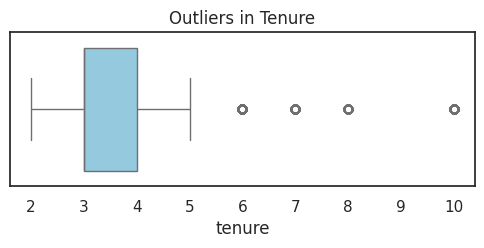

Note: We intentionally do NOT drop outliers. Random Forest handles them perfectly and senior employees (high tenure) are valid attrition risks in a real HR environment.


In [53]:
# 1. Check Outliers in df1
plt.figure(figsize=(6, 2))
plt.title('Outliers in Tenure', fontsize=12)
sns.boxplot(x=df1['tenure'], color='skyblue')
plt.savefig('visuals/outliers_tenure.png', bbox_inches='tight', dpi=300)
plt.show()

# 2. Portfolio Note
print("Note: We intentionally do NOT drop outliers. Random Forest handles them perfectly and senior employees (high tenure) are valid attrition risks in a real HR environment.")

In [54]:
# numbers of people who left vs. stayed
print(df1['left'].value_counts())
# percentages of people who left vs. stayed
print(df1['left'].value_counts(normalize=True))

left
0    10000
1     1991
Name: count, dtype: int64
left
0    0.833959
1    0.166041
Name: proportion, dtype: float64


# **EDA Visualizations**
---

### Plot 1. Monthly hours by number of projects

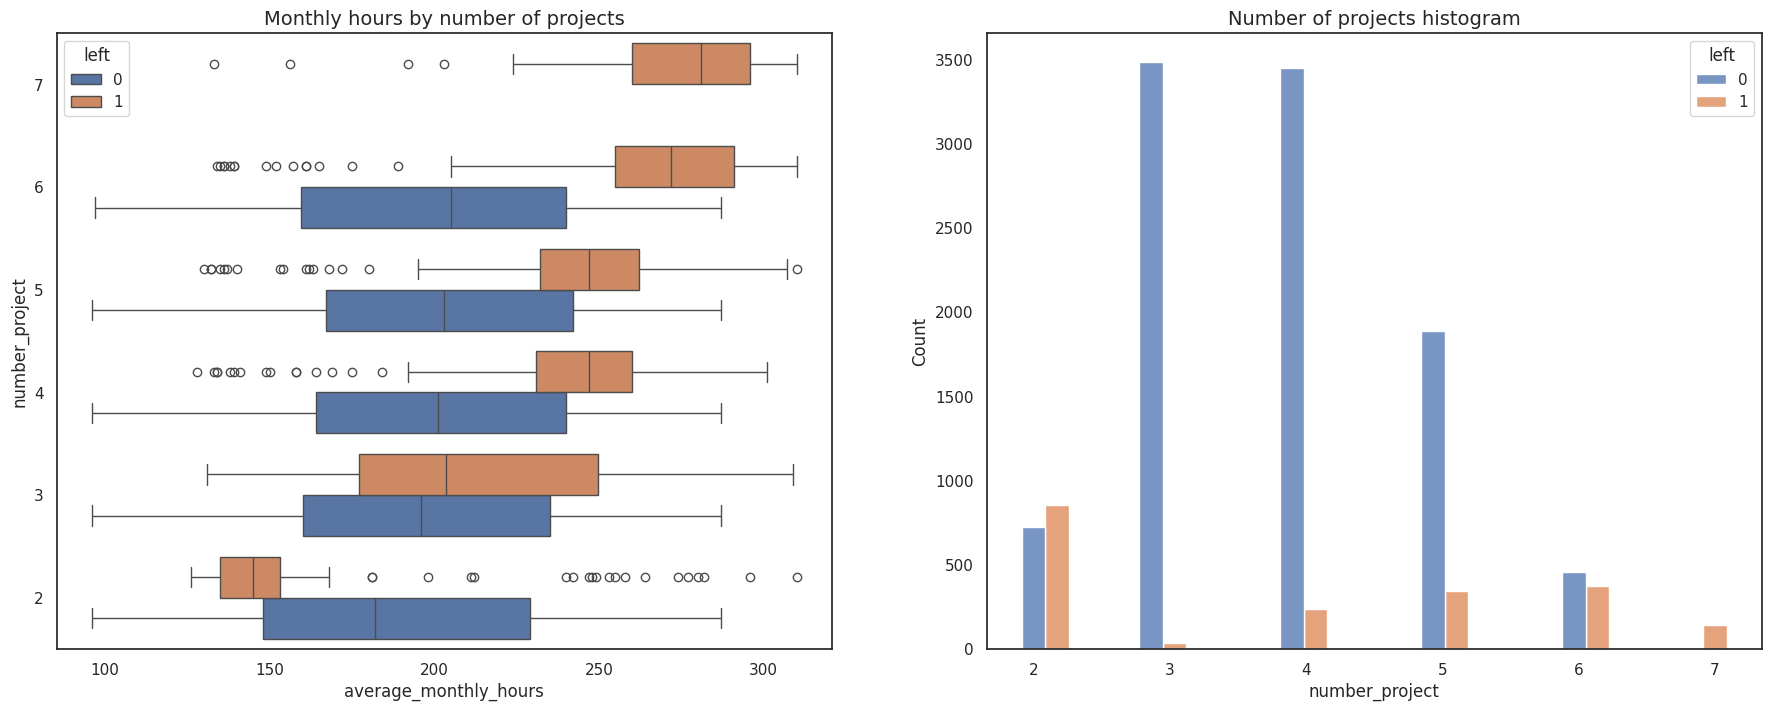

In [55]:
sns.set_theme(style="white")
fig, ax = plt.subplots(1, 2, figsize=(22,8))
sns.boxplot(data=df1, x='average_monthly_hours', y='number_project', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Monthly hours by number of projects', fontsize='14')

sns.histplot(data=df1, x='number_project', hue='left', multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Number of projects histogram', fontsize='14')
plt.savefig('visuals/eda_hours_by_projects.png', bbox_inches='tight', dpi=300)
plt.show()

### Plot 2. Monthly hours by last evaluation

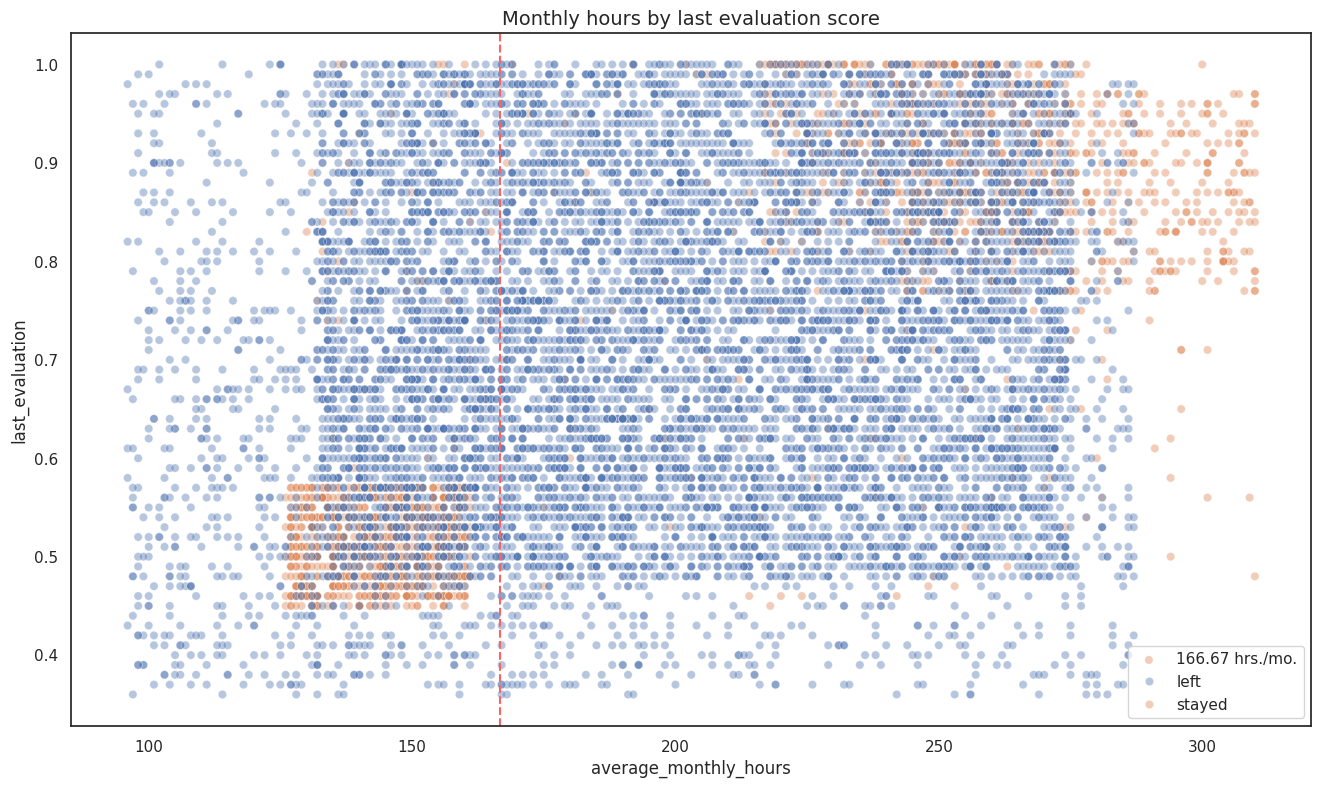

In [56]:
sns.set_theme(style="white")

plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='last_evaluation', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14')
plt.savefig('visuals/eda_hours_by_evaluation.png', bbox_inches='tight', dpi=300)
plt.show()

### Plot 3. Satisfaction by tenure


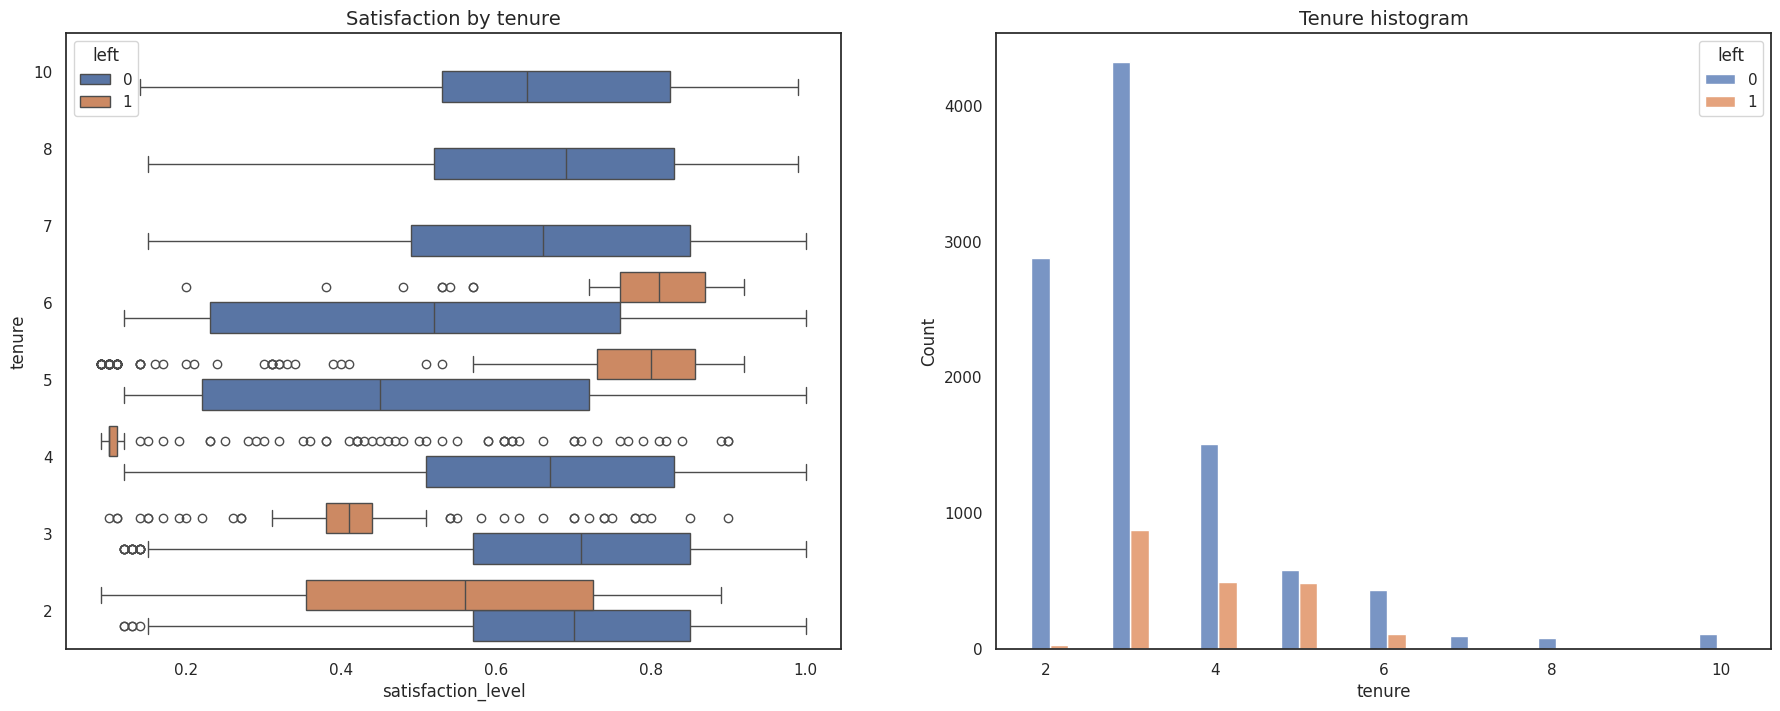

In [57]:
fig, ax = plt.subplots(1, 2, figsize=(22,8))
sns.boxplot(data=df1, x='satisfaction_level', y='tenure', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Satisfaction by tenure', fontsize='14')

sns.histplot(data=df1, x='tenure', hue='left', multiple='dodge', shrink=5, ax=ax[1])
ax[1].set_title('Tenure histogram', fontsize='14')
plt.savefig('visuals/eda_satisfaction_by_tenure.png', bbox_inches='tight', dpi=300)
plt.show()

### Plot 4. Salary by tenure


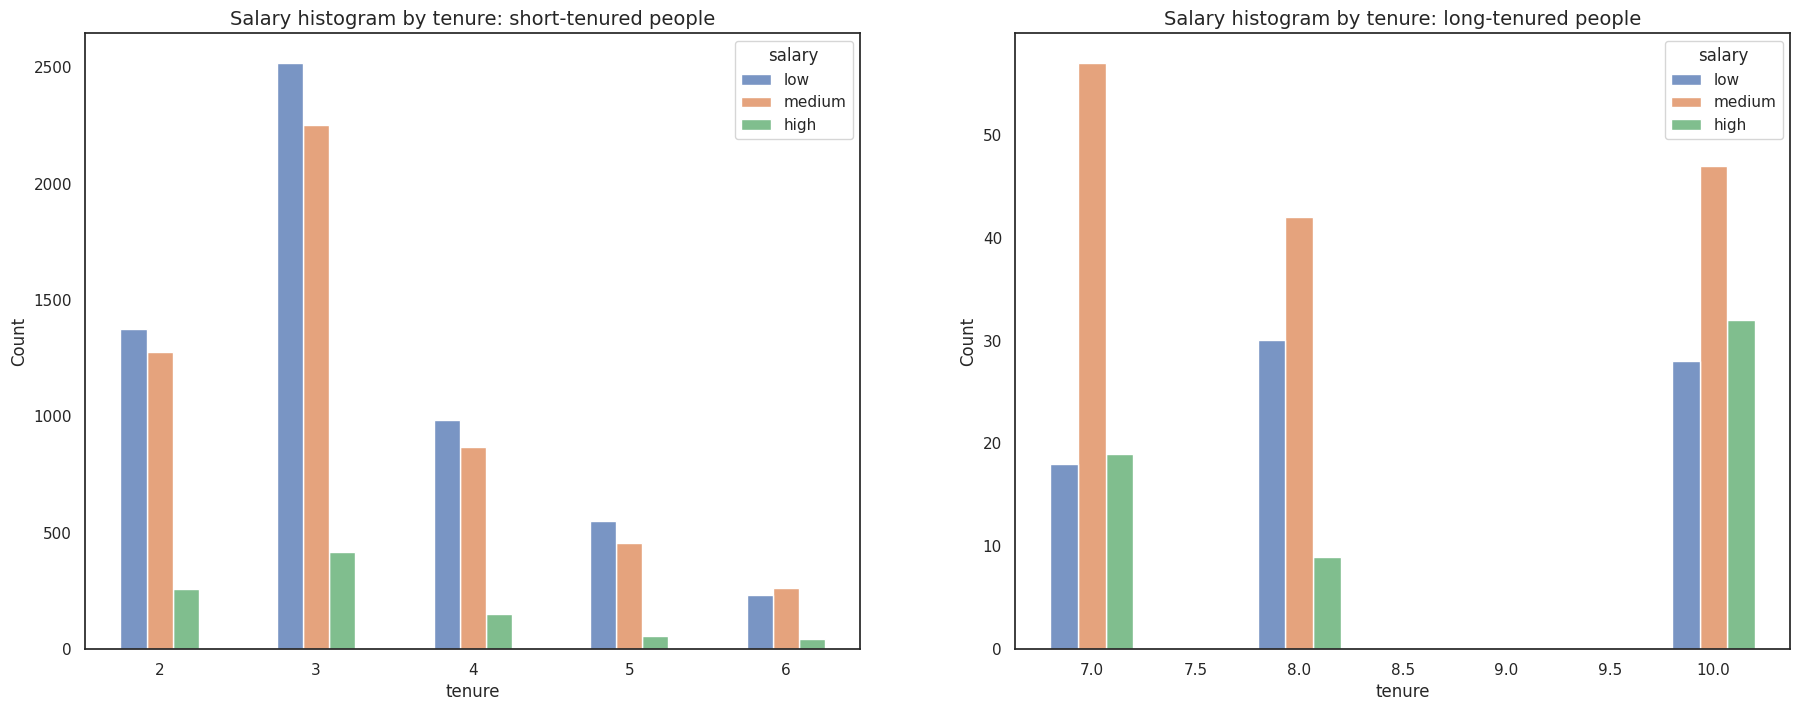

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(22,8))
tenure_short = df1[df1['tenure'] < 7]
tenure_long = df1[df1['tenure'] > 6]

sns.histplot(data=tenure_short, x='tenure', hue='salary', discrete=1, hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.5, ax=ax[0])
ax[0].set_title('Salary histogram by tenure: short-tenured people', fontsize='14')

sns.histplot(data=tenure_long, x='tenure', hue='salary', discrete=1, hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.4, ax=ax[1])
ax[1].set_title('Salary histogram by tenure: long-tenured people', fontsize='14')
plt.savefig('visuals/eda_salary_by_tenure.png', bbox_inches='tight', dpi=300)
plt.show()


### Plot 5. Counts of stayed/left by department


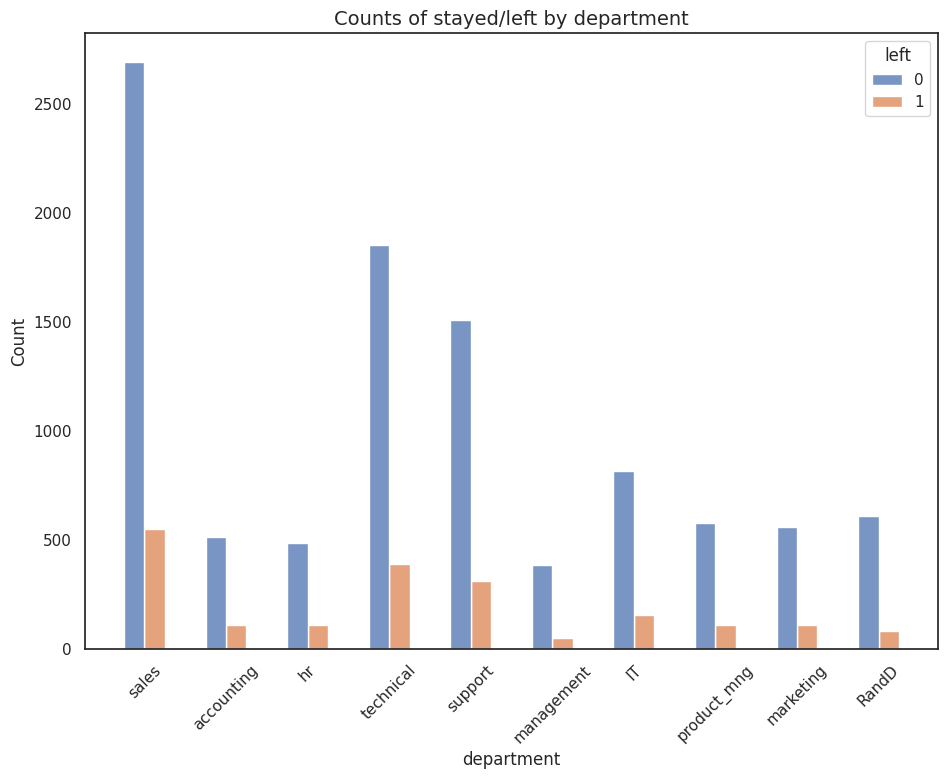

In [59]:
plt.figure(figsize=(11,8))
sns.histplot(data=df1, x='department', hue='left', discrete=1, hue_order=[0, 1], multiple='dodge', shrink=.5)
plt.xticks(rotation= 45)
plt.title('Counts of stayed/left by department', fontsize=14)
plt.savefig('visuals/eda_department_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

### Plot 6. Correlation Heatmap


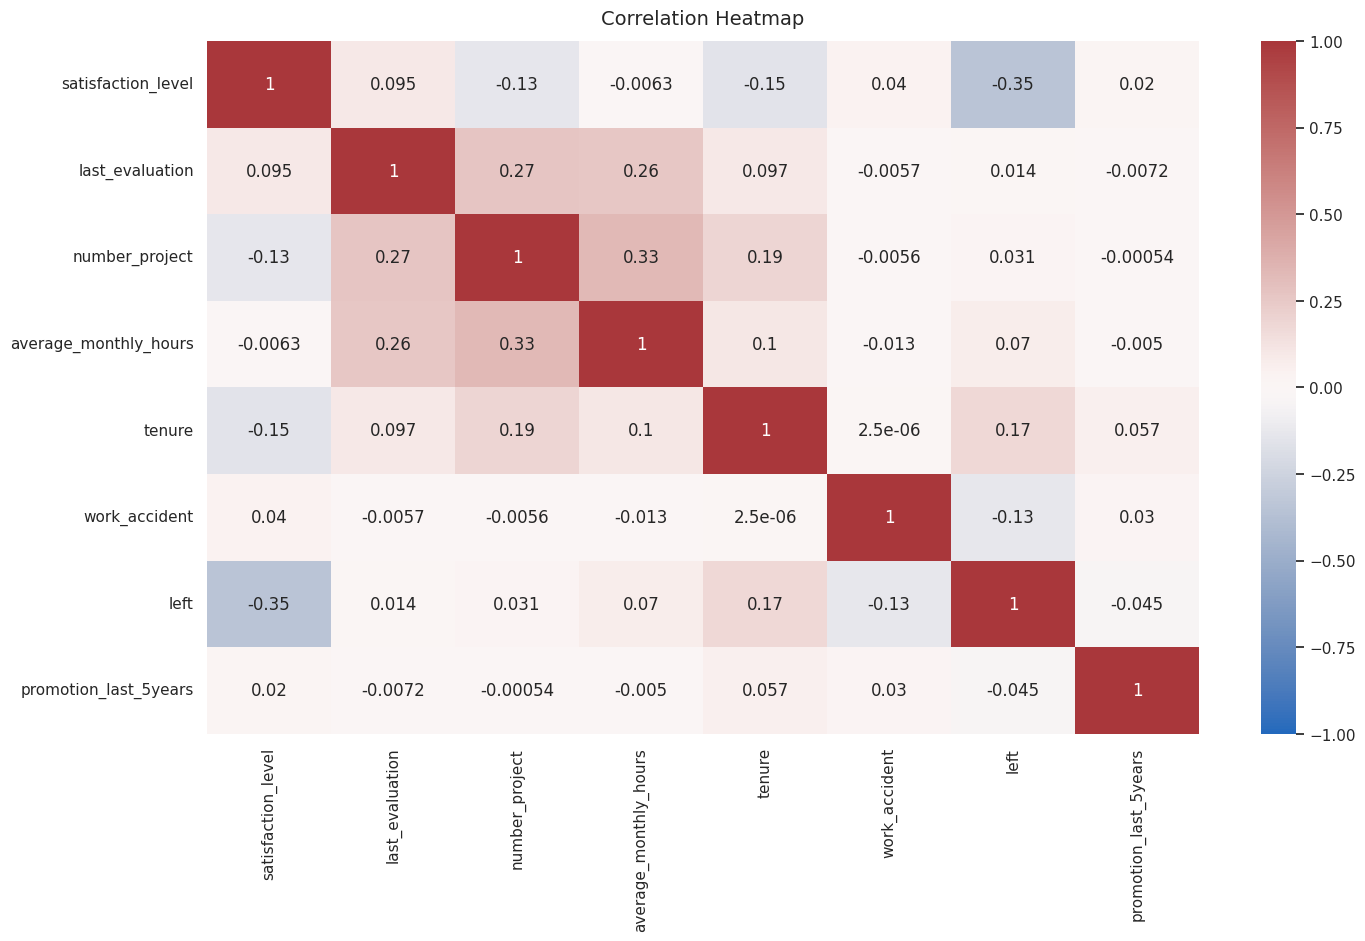

In [60]:
plt.figure(figsize=(16, 9))
numeric_df = df1.drop(['department', 'salary'], axis=1) # drop strings for correlation
heatmap = sns.heatmap(numeric_df.corr(), vmin=-1, vmax=1, annot=True, cmap=sns.color_palette("vlag", as_cmap=True))
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12)
plt.savefig('visuals/eda_correlation_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

# **PACE: Construct Stage**

#**Production Architecture Feature Engineering**
---

## 1. Feature Engineering with Scikit-Learn OneHotEncoder

In [61]:
cat_cols = ['department', 'salary']
num_cols = [col for col in df1.columns if col not in cat_cols and col != 'left']

# Initialize the Encoder (sparse_output=False guarantees a solid numpy array format)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and Transform Categorical Data using df1
encoded_cats = encoder.fit_transform(df1[cat_cols])
encoded_df = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out(cat_cols))

# Combine Numerical and Encoded Categorical Data
df_num = df1[num_cols].reset_index(drop=True)
X = pd.concat([df_num, encoded_df], axis=1)

# Isolate Target Variable securely
y = df1['left'].reset_index(drop=True)



## 2. Save cleaned dataset

In [62]:
X_concat = X.copy()
X_concat['left'] = y
X_concat.to_csv('cleaned_hr_data.csv', index=False)

### 3. Train-Test Split (80% / 20%)


In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set size:", len(X_train))

Training set size: 9592


 # **Baseline Model vs Main Model**
 ---

## STEP 1: Train Baseline Model (LogisticRegression)


In [64]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)

print(f"Baseline Model Accuracy (Logistic Regression): {acc_log:.4f}")
print("Portfolio Insight: Logistic Regression struggled due to ")
print("non-linear relationships (e.g., working hours vs attrition) ")
print("and existing outliers in tenure. We will now train a robust ")
print("Random Forest to capture these complex human patterns.")

Baseline Model Accuracy (Logistic Regression): 0.8345
Portfolio Insight: Logistic Regression struggled due to 
non-linear relationships (e.g., working hours vs attrition) 
and existing outliers in tenure. We will now train a robust 
Random Forest to capture these complex human patterns.


## STEP 2: Train Main Model (Random Forest)


In [65]:
# Hyperparameters set prevent overfitting and make SHAP explanations cleaner
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

# Make Predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"Main Model Accuracy (Random Forest): {acc:.4f}")

Main Model Accuracy (Random Forest): 0.9692


## Random Forest Visualizations

### Confusion Matrix

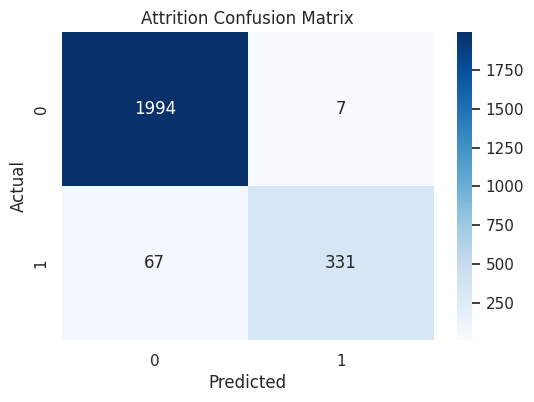

In [66]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Attrition Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('visuals/confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()

### ROC Curve

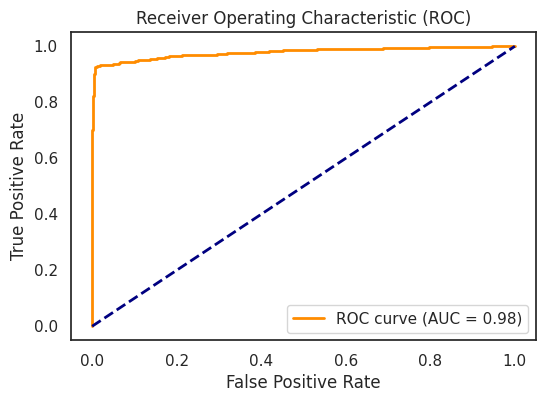

In [67]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.savefig('visuals/roc_curve.png', bbox_inches='tight', dpi=300)
plt.show()

# **Advanced Interpretability (SHAP & Importance)**
---

## Feature Importance Plot

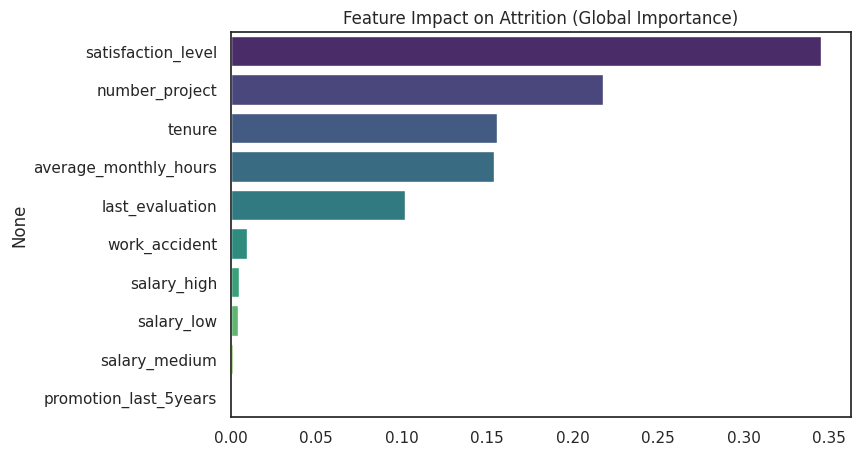

In [68]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(8, 5))
plt.title("Feature Impact on Attrition (Global Importance)")
sns.barplot(x=importances[indices][:10], y=X.columns[indices][:10], palette='viridis')
plt.savefig('visuals/feature_importance.png', bbox_inches='tight', dpi=300)
plt.show()

## SHAP Explainability Plot


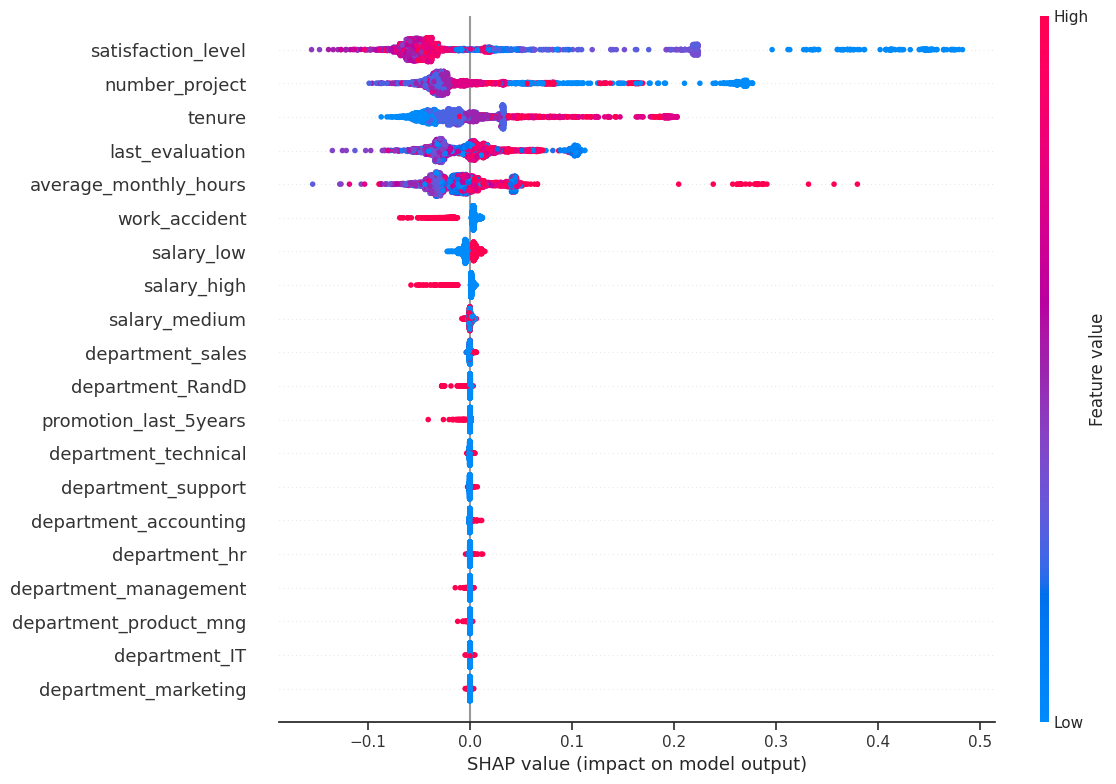

In [69]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

shap.summary_plot(shap_vals, X_test, plot_size=(12, 8), show=False)

plt.tight_layout()
plt.savefig('visuals/shap_summary.png', bbox_inches='tight', dpi=300)
plt.show()


#**Business Value - Actionable HR Table**
---

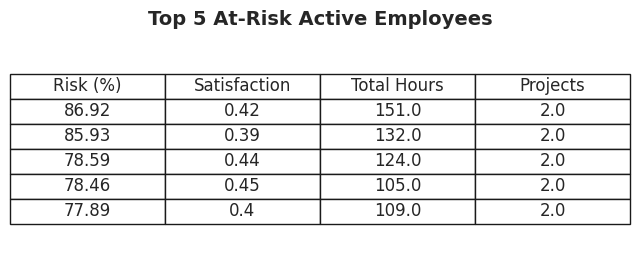

In [70]:
# 1. Generate Top 10 High-Risk Employees
df_current = X.copy()
df_current['Attrition_Risk_%'] = rf_model.predict_proba(X)[:, 1] * 100
df_current['Left_Company'] = y.values

# 2. Filter active employees (Left_Company == 0 means they haven't quit yet)
active_employees = df_current[df_current['Left_Company'] == 0].drop('Left_Company', axis=1)

# 3. Sort by highest risk
top_10_risk = active_employees.sort_values(by='Attrition_Risk_%', ascending=False).head(10)

# Generate Table Image for README
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')
table_data = top_10_risk[['Attrition_Risk_%', 'satisfaction_level', 'average_monthly_hours', 'number_project']].round(2).head(5)
table = ax.table(cellText=table_data.values, colLabels=['Risk (%)', 'Satisfaction', 'Total Hours', 'Projects'], loc='center', cellLoc='center')
table.scale(1, 1.5)
plt.title('Top 5 At-Risk Active Employees', fontsize=14, weight='bold')
plt.savefig('visuals/high_risk_table.png', bbox_inches='tight', dpi=300)
plt.show()


#**Serialize Assets for Local Application**
---

In [71]:
# Save Trained Machine Learning model
model_path = 'model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(rf_model, f)

# Save Categorical translation Encoder
encoder_path = 'encoder.pkl'
with open(encoder_path, 'wb') as f:
    pickle.dump(encoder, f)

print(f"Mission Accomplished! All local models and images are saved.")
print(f"1. {model_path} (Predictive Random Forest)")
print(f"2. {encoder_path} (Scikit-Learn Encoder)")
print("=> Once you click the folder icon on the left panel in Colab, download these two files AND the 'visuals' folder.")


Mission Accomplished! All local models and images are saved.
1. model.pkl (Predictive Random Forest)
2. encoder.pkl (Scikit-Learn Encoder)
=> Once you click the folder icon on the left panel in Colab, download these two files AND the 'visuals' folder.


In [72]:
import shutil

shutil.make_archive('visuals_folder', 'zip', 'visuals')

'/content/visuals_folder.zip'

In [73]:
import joblib
joblib.dump(X.columns.tolist(), "feature_columns.pkl")


['feature_columns.pkl']